In [12]:

'''PHASE 1 — TITANIC DATA CLEANING'''

#import the tools that will help us read and work with the our data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
'''step 1: Load the dataset'''


#We load the Titanic dataset so we can start exploring it
df = pd.read_csv("/content/sample_data/train.csv")

#We look at the first 5 rows to understand what kind of information we have
print(df.head(5))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [14]:
'''step 2: Check dataset size'''


#This shows how many passengers (rows) and how many details (columns) we have
print(df.shape)

(891, 12)


In [15]:
'''step 3: Look at column types and missing values'''


#This helps us see what kind of data each column contains...and if there are any missing values that need fixing
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [16]:
'''step 4 Fix column types'''

#Some columns look like numbers, but they actually represent groups.
#For example, passenger class (1, 2, 3) is not a number we calculate with,
#it simply shows which group the passenger belongs to. So we change these columns to categorize to reflect their real meaning.

df["Pclass"] = df["Pclass"].astype("category")
df["Survived"] = df["Survived"].astype("category")
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

In [17]:
'''step 5: Check missing values'''


#Here we count how many missing values exist in each column.
#This helps us decide what needs to be cleaned.
print (df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [18]:
'''step 6 : handle missing values'''


#The Cabin column has too many missing values.
#Since most of the information is missing, we cannot confidently guess or fill it.
#So we remove this column to keep the data reliable.


#Some passengers are missing their age.
#Instead of guessing randomly, we fill missing ages. with the middle value (median).
#We choose the middle value because it is not affected, by very young or very old passengers.
df["Age"] = df["Age"].fillna(df["Age"].median())
print(df)
#A few passengers are missing their port of embarkation.
#Since only a small number is missing, we fill them with the most common port in the dataset.
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
print(df)

     PassengerId Survived Pclass  \
0              1        0      3   
1              2        1      1   
2              3        1      3   
3              4        1      1   
4              5        0      3   
..           ...      ...    ...   
886          887        0      2   
887          888        1      1   
888          889        0      3   
889          890        1      1   
890          891        0      3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ...    ...   
886           

In [19]:
'''step 7: Check for duplicates'''

#We check if there are any repeated passengers in the dataset.
#Duplicates could affect our results.
print (df.duplicated().sum())

#If duplicates exist, we remove them to keep each passenger unique.
df = df.drop_duplicates()

0


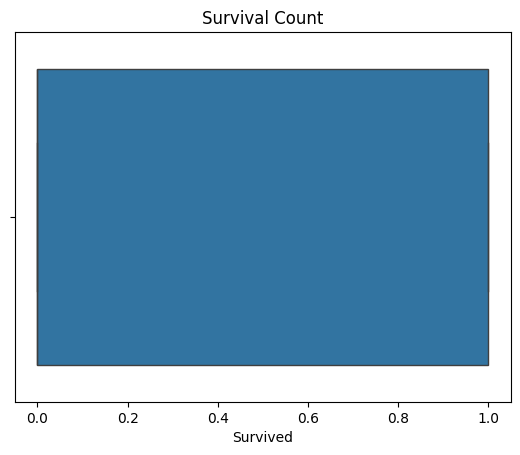

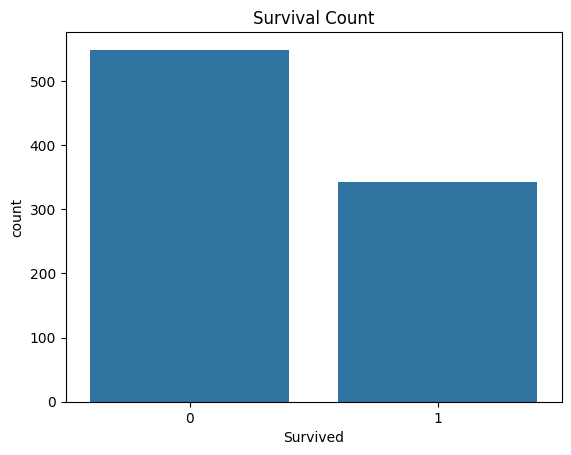

In [20]:
'''step 8: Check target column for extreme values'''


#The target column (Survived) only has two values: 0 and 1.
#this means there are no extreme values to fix.
sns.boxplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

#or we also can use count plot for more clear results

sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

In [21]:
'''''step 9: Create cleaning function (pipline)'''''


#Now we create a function that repeats all cleaning steps.
#This makes our work organized and easy to reuse later.

def clean_data(df):
    df = df.copy()

    df["Pclass"] = df["Pclass"].astype("category")
    df["Survived"] = df["Survived"].astype("category")
    df["Sex"] = df["Sex"].astype("category")
    df["Embarked"] = df["Embarked"].astype("category")

    df = df.drop(columns=["Cabin"])

    df["Age"] = df["Age"].fillna(df["Age"].median())
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    df = df.drop_duplicates()

    return df

In [22]:
''' step 10: Apply the function'''


#We apply the cleaning function to make sure everything works correctly
df = clean_data(df)
print(df)

     PassengerId Survived Pclass  \
0              1        0      3   
1              2        1      1   
2              3        1      3   
3              4        1      1   
4              5        0      3   
..           ...      ...    ...   
886          887        0      2   
887          888        1      1   
888          889        0      3   
889          890        1      1   
890          891        0      3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ...    ...   
886           

In [23]:
'''step 11: Final checks'''


#These checks confirm that cleaning worked properly.

#Make sure there are no missing ages left
assert df["Age"].isnull().sum() == 0

#Make sure there are no missing embarkation values
assert df["Embarked"].isnull().sum() == 0

#Make sure the Cabin column was successfully removed
assert "Cabin" not in df.columns

In [24]:
'''PHASE 1 — TITANIC DATA CLEANING...COMPLETED'''

'PHASE 1 — TITANIC DATA CLEANING...COMPLETED'